# 時系列が耐えられる交差検証

バックテストは起きたことを測ります。交差検証はもっと難しい問いに答えるはずのものです。
勝ったパラメータは理由があって選ばれたのか、それとも試した中でいちばん運が良かっただけなのか。
ふつうの k 分割はマーケットデータでその問いに答えられません。理由は2つあり、どちらもモデルとは
関係ありません。

1つ目は重なりです。1か月保有するシグナルのラベルは1か月にまたがるので、保有期間がテスト
ブロックに届いている学習データの観測は、すでにテスト期間を見ています。2つ目は系列相関です。
分割の境界の両側にある観測はほとんど同じ観測なので、学習データに隣接したテストセットは、
役に立つ意味ではアウトオブサンプルではありません。

`quant.validation` は両方を構造的に解決します。ラベルが重なる学習行をパージし、各テスト
ブロックの直後をエンバーゴします。そして `quant.overfitting` が、それを生んだ探索のあとに
結果として何が残るのかを値付けします。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| ラベル | 観測を採点する相手となる結果。ここでは先行リターン |
| 期間（ホライズン） | ラベルが何観測ぶん先まで届くか |
| パージ | ラベルがテストブロックに重なる学習行を落とすこと |
| エンバーゴ | テストブロック直後の学習行を落とすこと。ほぼ同じデータだから |
| ウォークフォワード | 過去で学習し、その次の期間でテストすることを繰り返す方式 |
| CPCV | 組み合わせパージド交差検証。テスト経路が1本ではなく、多数になる |
| PBO | バックテスト過剰適合確率。インサンプルの勝者がアウトオブサンプルで負ける頻度 |
| デフレーテッド・シャープ | 試した戦略の数で補正したシャープレシオ |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import h5i_db
from h5i_db import col, quant, sql_expr
import cookbook_utils as cu

HOLD = 21

## 1. 選ぶ相手となる候補

探索するパラメータは1つ、モメンタムのルックバックです。候補ごとに、上位分位と下位分位の
ロングショート・スプレッドの日次リターン系列を作ります。計算は `quant.build_panel` を通じて
エンジンの中で行います。

同じ日付にわたって候補ごとに1系列。これが以下のすべての道具が求める行列そのものです。

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
db = h5i_db.Database(cu.fresh_db("06_cross_validation_without_leakage"), create=True)
prices = daily.sort_by([("ts", "ascending"), ("symbol", "ascending")])
db.create_table("prices", prices.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices, note="30 large caps, 2018-2026")
db.snapshot("prices-v1", tables=["prices"], note="Every candidate reads this cut")

LOOKBACKS = (21, 42, 63, 126, 189, 252)
pinned = db.table("prices", snapshot="prices-v1")
price_frame = pinned.select(ts=col("ts"), asset=col("symbol"), price=col("adj_close"))

series = {}
for lookback in LOOKBACKS:
    factor = (
        pinned.with_columns(
            past=sql_expr(f"lag(adj_close, {lookback})").over(
                partition_by="symbol", order_by="ts"
            )
        )
        .with_columns(value=col("adj_close") / col("past") - 1)
        .select(ts=col("ts"), asset=col("symbol"), factor=col("value"))
    )
    panel = quant.build_panel(db, factor, price_frame, periods=(HOLD,), quantiles=5)
    spread = panel.spread().to_pandas()[["ts", f"spread_{HOLD}"]]
    series[f"mom_{lookback}"] = spread.set_index("ts")[f"spread_{HOLD}"]

candidates = pd.DataFrame(series).dropna()
candidates.index = pd.DatetimeIndex(candidates.index)
print(f"{len(candidates):,} dates x {candidates.shape[1]} candidates")
candidates.tail(3).round(4)

1,861 dates x 6 candidates


,mom_21,mom_42,mom_63,mom_126,mom_189,mom_252
ts,,,,,,
2026-05-27 20:00:00+00:00,0.0123,-0.0040,-0.0536,-0.0520,0.0382,0.0002
2026-05-28 20:00:00+00:00,0.0696,0.0309,-0.0218,-0.0433,0.0704,0.0211
2026-05-29 20:00:00+00:00,0.0476,0.0541,-0.0081,-0.0342,0.0895,0.0343


各列は、上位分位を下位分位に対して `HOLD` 日保有したリターンで、ポジションを組成した日で
日付が付いています。この日付の付け方が重なりを明示します。どの行のラベルも21行ぶん先まで
届いています。

In [3]:
scores = candidates.mean() / candidates.std() * np.sqrt(252)
print("in-sample Sharpe of each candidate, whole history:")
print(scores.round(3).to_string())
print(f"\nbest in sample: {scores.idxmax()}")

in-sample Sharpe of each candidate, whole history:
mom_21     0.232
mom_42     1.362
mom_63     0.632
mom_126    1.026
mom_189    1.290
mom_252    0.814

best in sample: mom_42


## 2. パージが取り除くもの

`purged_kfold` はサンプルを連続したブロックに切り、それぞれについて、ラベルがテストブロックに
届く学習行とエンバーゴに入る学習行を落とします。落とした件数が、パージしない分割で生じていた
リークの大きさです。

In [4]:
n = len(candidates)
horizons = [HOLD] * n
splits = list(quant.purged_kfold(n, folds=5, horizons=horizons, embargo=0.01))
folds = pd.DataFrame(
    [
        {
            "fold": index,
            "train": split.train_size,
            "test": split.test_size,
            "purged": len(split.purged),
            "purged %": len(split.purged) / (split.train_size + len(split.purged)),
        }
        for index, split in enumerate(splits)
    ]
)
folds.round(4)

,fold,train,test,purged,purged %
0,0,1470,372,19,0.0128
1,1,1449,372,40,0.0269
2,2,1448,373,40,0.0269
3,3,1449,372,40,0.0269
4,4,1468,372,21,0.0141


パージされた行がリークであり、均等には散らばりません。内側の分割は学習データの両側に
テストブロックがあるので、最初や最後の分割の2倍を失います。素朴な k 分割はこれらの行を
すべて残します。

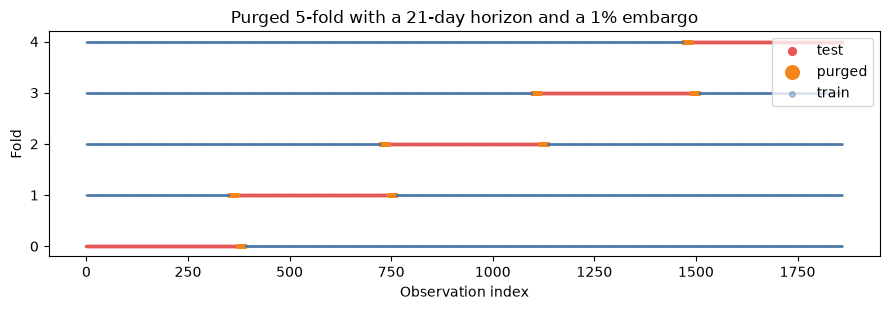

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for index, split in enumerate(splits):
    ax.scatter(split.test, [index] * split.test_size, s=2, color="#e45756", label="test" if index == 0 else None)
    ax.scatter(split.purged, [index] * len(split.purged), s=6, color="#f58518", label="purged" if index == 0 else None)
    ax.scatter(split.train, [index] * split.train_size, s=1, color="#4c78a8", alpha=0.4, label="train" if index == 0 else None)
ax.set_title(f"Purged 5-fold with a {HOLD}-day horizon and a 1% embargo")
ax.set_xlabel("Observation index")
ax.set_ylabel("Fold")
ax.legend(loc="upper right", markerscale=4)
fig.tight_layout()

## 3. リークは答えを変えるのか

パージしない分割で選ぶことと、パージした分割で選ぶことは、2つの手続きです。両方を走らせて
選択を比べることだけが、このデータでリークが効いたのか、インサンプルのスコアの何点ぶんだった
のかを知る方法です。

In [6]:
def sharpe(values) -> float:
    values = np.asarray(values, dtype=float)
    if values.size < 2 or values.std(ddof=1) == 0:
        return float("nan")
    return float(values.mean() / values.std(ddof=1) * np.sqrt(252))


naive = [
    quant.validation.Split(
        train=tuple(i for i in range(n) if not (split.test[0] <= i <= split.test[-1])),
        test=split.test,
    )
    for split in splits
]

comparison = []
for label, chosen in (("naive k-fold", naive), ("purged + embargo", splits)):
    train_scores, test_scores = {}, {}
    for name in candidates.columns:
        column = candidates[name].to_numpy()
        train_scores[name] = np.mean([sharpe(column[list(s.train)]) for s in chosen])
        test_scores[name] = np.mean([sharpe(column[list(s.test)]) for s in chosen])
    winner = max(train_scores, key=train_scores.get)
    comparison.append(
        {
            "procedure": label,
            "train rows": sum(s.train_size for s in chosen),
            "picked": winner,
            "train Sharpe of pick": train_scores[winner],
            "test Sharpe of pick": test_scores[winner],
        }
    )
pd.DataFrame(comparison).round(3)

,procedure,train rows,picked,train Sharpe of pick,test Sharpe of pick
0,naive k-fold,7444,mom_42,1.358,1.265
1,purged + embargo,7284,mom_42,1.349,1.265


このデータではどちらの手続きも同じ候補を選び、パージした側は学習行がおよそ2%少ない状態で
その判断に到達しています。持つ価値のある結果ですが、「パージは要らない」とは別物です。
リークが答えを変えなかったと言える唯一の方法は、両方で答えを計算することです。2つが食い違う
とき、テストセットを見ていたのはパージしていないほうです。

## 4. 1つの数字ではありません。多数の経路です

5分割はアウトオブサンプルの推定値を1つ与えますが、その推定値にも誤差幅があり、誰もそれを
引用しません。組み合わせパージド交差検証は、代わりにブロックのあらゆる組み合わせでテストする
ので、出力は同じ候補についての結果の *分布* になります。

In [7]:
paths = list(quant.combinatorial_purged(n, groups=6, test_groups=2, horizons=horizons, embargo=0.01))
picked = comparison[-1]["picked"]
column = candidates[picked].to_numpy()
path_scores = np.array([sharpe(column[list(split.test)]) for split in paths])
print(f"{len(paths)} paths from C(6, 2)")
print(f"median   {np.nanmedian(path_scores):.3f}")
print(f"quartiles{np.nanpercentile(path_scores, 25):8.3f} to {np.nanpercentile(path_scores, 75):.3f}")
print(f"worst    {np.nanmin(path_scores):.3f}")
print(f"share of paths below zero: {(path_scores < 0).mean():.0%}")

15 paths from C(6, 2)
median   1.280
quartiles   0.234 to 2.343
worst    -1.668
share of paths below zero: 13%


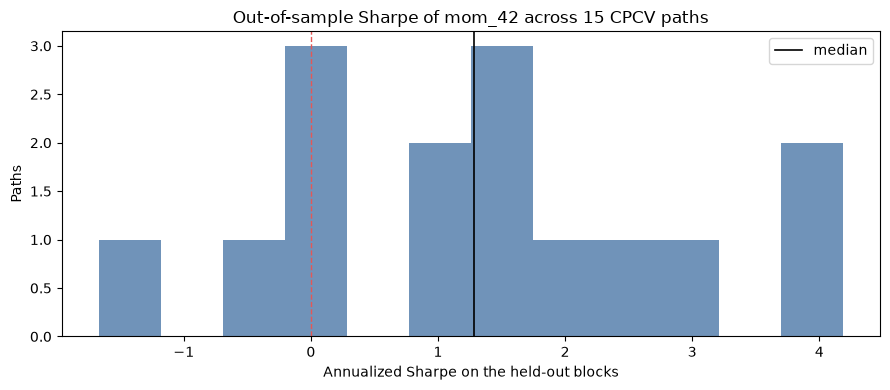

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(path_scores, bins=12, color="#4c78a8", alpha=0.8)
ax.axvline(np.nanmedian(path_scores), color="black", linewidth=1.2, label="median")
ax.axvline(0, color="#e45756", linewidth=1.0, linestyle="--")
ax.set_title(f"Out-of-sample Sharpe of {picked} across {len(paths)} CPCV paths")
ax.set_xlabel("Annualized Sharpe on the held-out blocks")
ax.set_ylabel("Paths")
ax.legend()
fig.tight_layout()

## 5. ウォークフォワード、つまり本番の姿

交差検証は、前半の分割にとっての学習データとして未来を使い回します。*手続きを評価する*
目的では正当ですが、デスクが実際に走らせられたものの説明としては不誠実です。ウォーク
フォワードは過去だけで学習します。

In [9]:
rolling = list(quant.walk_forward(n, train_size=500, test_size=125, horizons=horizons, embargo=0.01))
expanding = list(
    quant.walk_forward(n, train_size=500, test_size=125, horizons=horizons, embargo=0.01, expanding=True)
)
def walk_selection(chosen) -> pd.DataFrame:
    """Pick on each fold's training window, score on the block that follows."""
    picks = []
    for index, split in enumerate(chosen):
        train_pick = max(
            candidates.columns,
            key=lambda name: sharpe(candidates[name].to_numpy()[list(split.train)]),
        )
        picks.append(
            {
                "fold": index,
                "picked": train_pick,
                "test Sharpe": sharpe(candidates[train_pick].to_numpy()[list(split.test)]),
            }
        )
    return pd.DataFrame(picks)


walk = pd.DataFrame(
    [
        {
            "window": label,
            "folds": len(chosen),
            "first train size": chosen[0].train_size,
            "last train size": chosen[-1].train_size,
            "changed its mind": walk_selection(chosen)["picked"].nunique(),
            "mean test Sharpe of its pick": walk_selection(chosen)["test Sharpe"].mean(),
        }
        for label, chosen in (("rolling", rolling), ("expanding", expanding))
    ]
)
walk.round(3)

,window,folds,first train size,last train size,changed its mind,mean test Sharpe of its pick
0,rolling,10,479,479,5,-0.865
1,expanding,10,479,1604,3,-0.282


2つの違いは、学習窓が最も古いデータを捨てるかどうかだけです。その選択は、相場がどれだけ
速く変わるかについての主張であり、既定値に埋めずレポートに書くべきものです。

In [10]:
walk_choices = walk_selection(rolling)
print(f"the rolling procedure changed its mind {walk_choices['picked'].nunique()} times")
print(f"mean test Sharpe of what it picked: {walk_choices['test Sharpe'].mean():.3f}")
walk_choices.round(3)

the rolling procedure changed its mind 5 times
mean test Sharpe of what it picked: -0.865


,fold,picked,test Sharpe
0,0,mom_126,-1.974
1,1,mom_42,-1.794
2,2,mom_63,7.653
3,3,mom_63,-5.135
4,4,mom_189,-3.781
5,5,mom_63,-9.622
6,6,mom_42,10.561
7,7,mom_42,-1.256
8,8,mom_42,-2.600
9,9,mom_252,-0.705


この表で平均より価値があるものが2つあります。手続きが何度も考えを変えていること。これは
安定したエッジのないパラメータを内側から見た姿です。そして分割ごとのシャープが、年率換算した
数字としてありえない幅で振れていること。125日のブロックは、その統計量が単独で意味を持つには
短すぎます。セクション4で単一の分割よりも分布を見る理由は、まさにそこにあります。

## 6. 探索に値段をつける

上のどの数字も、6つの候補にわたる探索から出てきました。`quant.overfitting` は、その回数を
但し書きから補正に変えます。

`probability_of_backtest_overfitting` は行列全体（同じ日付にわたる、候補ごとに1列）を受け取り、
インサンプルの勝者がアウトオブサンプルで下位半分に落ちる頻度を問います。PBO が0.5付近なら、
選択にはまったく情報がなかったということです。

In [11]:
pbo = quant.probability_of_backtest_overfitting(candidates.to_numpy(), partitions=8)
print(f"PBO                  {pbo.pbo:.3f}")
print(f"splits evaluated     {pbo.splits}")
print(f"strategies compared  {pbo.strategies}")

PBO                  0.800
splits evaluated     70
strategies compared  6


デフレーテッド・シャープは、勝者だけについて補完的な問いを立てます。6つの候補を試したことを
踏まえると、そのシャープのうちどれだけが「6回引いた最大値」として期待される分なのか。

In [12]:
best = candidates[picked].to_numpy()
deflated = quant.deflated_sharpe(best, trials=len(LOOKBACKS), trials_source="counted")
print(f"observed Sharpe (per day)  {deflated.sharpe:.4f}")
print(f"benchmark from {deflated.trials} trials     {deflated.benchmark:.4f}")
print(f"probability it is real     {deflated.probability:.3f}")
print(f"significant at 95%         {deflated.is_significant}")

needed = quant.minimum_track_record_length(best, benchmark=0.0, confidence=0.95)
print(f"\nobservations available     {len(best):,}")
print(f"observations needed        {needed:,.0f}")

observed Sharpe (per day)  0.0858
benchmark from 6 trials     0.0302
probability it is real     0.990
significant at 95%         True

observations available     1,861
observations needed        388


`trials_source="counted"` は飾りではありません。台帳から数えた試行回数と、分析者が主張した
試行回数は、置ける信頼が違います。探索が `backtest.study` を通った場合に回数がどこから来るのかは、
レシピ 04/12 が示しています。

2つの答えは反対を向いていて、どちらも正しいものです。別々の問いだからです。デフレーテッド・
シャープは *この系列* がコイン投げ6回ぶんを上回るかを問い、上回っています。PBO はインサンプルの
勝者を選ぶことが良い選び方かを問い、そうではありません。候補は1つのアイデアの変種で、相関が
高く、ほとんどが正なので、ファミリー全体はエッジを持つ一方、その中の順位はノイズです。

実務的な読み方は、勝者ひとつを選ばずファミリーを売買するか、両方の数字を報告して読み手にこの緊張を
見せることです。

In [13]:
verdict = pd.DataFrame(
    [
        {"question": "does selection carry information?", "number": f"PBO {pbo.pbo:.2f}",
         "answer": "yes" if pbo.pbo < 0.5 else "no"},
        {"question": "is the winner's Sharpe real?", "number": f"p {deflated.probability:.2f}",
         "answer": "yes" if deflated.is_significant else "not yet"},
        {"question": "is the track record long enough?",
         "number": f"{len(best):,} of {needed:,.0f}",
         "answer": "yes" if len(best) >= needed else "no"},
    ]
)
verdict

,question,number,answer
0,does selection carry information?,PBO 0.80,no
1,is the winner's Sharpe real?,p 0.99,yes
2,is the track record long enough?,"1,861 of 388",yes


## まとめ

- 重なるラベルはリークします。ラベルがどこまで届くかを分割器に伝えるのが `horizons` で、
  省略することはラベルが瞬間的だという主張になります。
- エンバーゴはパージが扱わないものを扱います。テストブロックに隣接する観測は、ほぼテスト
  ブロックそのものです。
- CPCV はアウトオブサンプル結果の分布を返します。その分布の幅が、バックテストの正直な
  誤差幅です。
- デスクが実際に走らせられたものを説明できるのはウォークフォワードだけです。交差検証は
  手続きを評価するものであって、運用実績ではありません。
- PBO、デフレーテッド・シャープ、最小トラックレコード長は3つの別の問いで、結果はその3つ
  すべてに答えるべきです。
- ここでの候補はすべて1つのピン留めされたスナップショットを読むので、比較はデータどうし
  ではなく、パラメータどうしになります。

In [14]:
db.close()